이 노트북을 실행하는 데 필요한 라이브러리(표준 라이브러리 제외)
- torch
- torchvision
- numpy
- matplotlib

예제 실행 및 시각화를 위해 공통 라이브러리를 불러온다.
(공통 라이브러리에 대한 설명은 `code_reference/README.md` 파일을 참조)

In [1]:

# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz
# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib에서 한글 폰트 사용 설정
common.set_korean_plot_env()

다음 셀은 결과 재현성을 보장하기 위해서 시드를 고정한다. 여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.

In [2]:

import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 5-1 딥러닝에 맞는 이미지 취급법

본 노트북은 본문 5-1절의 코드 예제와 관련 내용을 다룬다. 주요 내용은 다음과 같다.
- 두 텐서 사이의 합성곱 연산
- 합성곱 필터를 이미지 전체에 적용해 만드는 특징 지도
- 풀링으로 특징 지도 요약하기

> **[그림 5-1], [그림 5-2], [그림 5-3]을 만드는 코드는 4-3절 예제 노트북(`04-03_example.ipynb`)에 있다.**
> 세 그림은 4-3절에서 학습한 다층 퍼셉트론 숫자 분류기의 한계를 보여 주는 것이라, 그 모델이 있는 노트북에 두었다.
> 혼동 행렬 히트맵, 주요 오답 패턴별 오분류 샘플, 두 픽셀 이동한 이미지의 분류 결과를 확인하려면 해당 노트북의 마지막 부분을 참고하자.

## 합성곱 연산

- 합성곱은 같은 크기의 두 텐서에서 같은 위치의 요소끼리 곱한 뒤 모두 더하는 연산이다.
    - 결과는 스칼라값 하나다.
- 딥러닝 교재나 논문에서는 합성곱 연산자로 `*` 기호를 쓰는 것이 관례이며, 행렬 곱셈과는 다른 연산이다.

In [3]:
######################################################################################
# 코드 5-1 - 두 텐서 사이의 합성곱 연산
######################################################################################

# 두 텐서에서 위치가 같은 원소끼리 곱한 후 모두 더하는 합성곱 연산 함수
def conv_operation(tensor_1, tensor_2):
    if tensor_1.shape != tensor_2.shape:
        raise ValueError('형태가 같은 텐서끼리만 합성곱 계산이 가능합니다.')
    return torch.sum(tensor_1 * tensor_2).item()    # 합성곱 연산 결과는 스칼라


tensor_1 = torch.tensor([[1, 2], [3, 4]])
tensor_2 = torch.tensor([[5, 6], [7, 8]])
print(conv_operation(tensor_1, tensor_2))

70


- 이미지에서 윤곽선이나 텍스처 같은 구조를 찾으려면, 목적에 맞는 필터로 모든 픽셀에서 합성곱 연산을 하면 된다.
- `make_feature_map()` 함수는 이미지 전체를 필터와 합성곱 연산해, 각 부분 영역의 연산 결과를 원래 위치에 맞게 재구성한 텐서를 반환한다.
    - 3x3 필터를 쓰면 28x28 이미지의 가장자리를 제외한 26x26 픽셀에서만 연산할 수 있어 (26, 26) 형태의 텐서가 만들어진다.

In [4]:
######################################################################################
# 코드 5-2 - 합성곱 필터를 이미지 전체에 적용
######################################################################################

from torchvision import datasets, transforms

# 합성곱 필터를 이미지 전체에 적용해 특징 지도를 만드는 함수
def make_feature_map(img_tensor, conv_filter):
    # img_tensor(이미지 텐서): 1 채널 이미지 (1, H, W) 형태
    _, H, W = img_tensor.shape
    # conv_filter(필터): (F_H, F_W) 형태의 텐서 (F_H, F_W는 각각 필터 세로, 가로 크기)
    F_H, F_W = conv_filter.shape
    # 빈 특징 지도를 합성곱 연산 결과로 채움
    feature_map = torch.zeros((H - F_H + 1, W - F_W + 1))
    # 합성곱 필터를 한 픽셀씩 이동하면서 이미지 전체에 적용
    for y in range(H - F_H + 1):
        for x in range(W - F_W + 1):
            # 이미지의 3x3 부분 영역을 (3, 3) 형태의 텐서로 슬라이싱
            partial_img = img_tensor[0, y:y + F_H, x:x + F_W]
            # 부분 영역 텐서와 필터 텐서의 합성곱 연산
            conv_value = conv_operation(partial_img, conv_filter)
            feature_map[y, x] = conv_value
    return feature_map

# data_root: MNIST 데이터셋을 다운로드할 경로
data_root = '../../download'

# 특징 지도 확인 용도이므로 텐서 변환(ToTensor)만 적용
test_set = datasets.MNIST(root=data_root, train=False, download=True, 
                          transform=transforms.ToTensor())

# 왼쪽이 밝고, 오른쪽이 어두운 세로 방향 경계선을 탐지하는 필터
vertical_filter = torch.tensor(
    [[1., 0., -1.], 
     [1., 0., -1.], 
     [1., 0., -1.]]
)

# 이미지 샘플의 세로 방향 경계선 특징 지도 생성
feature_map = make_feature_map(test_set[0][0], vertical_filter)

print(f'특징 지도의 형태: {tuple(feature_map.shape)}')   # (26, 26)

특징 지도의 형태: (26, 26)


- 0부터 9까지 각 숫자 샘플에 세로 경계 필터를 적용해 만든 특징 지도를 확인한다([그림 5-7]).
    - 합성곱 연산값이 클수록 밝게 나타나며, 주로 세로 방향 획의 오른쪽 경계가 밝게 그려진다.

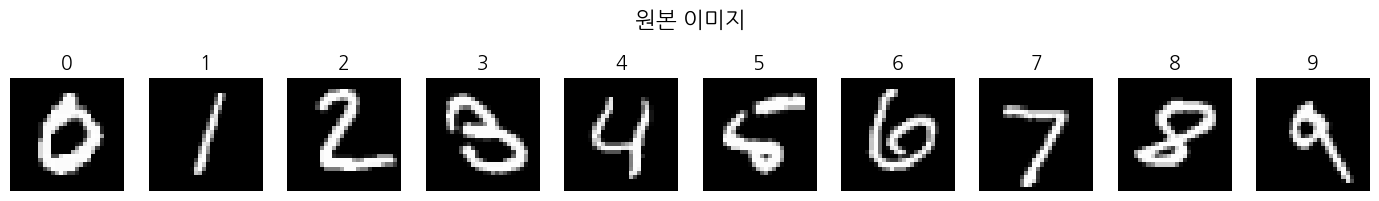

In [5]:
# 참고 - 각 숫자별 샘플에 세로 경계 필터를 적용해 만든 특징 지도 시각화([그림 5-7])

# 0~9 각 숫자의 첫 번째 테스트 샘플(원본) 시각화
first_indices = {}
for idx in range(len(test_set)):
    _, label = test_set[idx]
    if label not in first_indices:
        first_indices[label] = idx
    if len(first_indices) == 10:
        break

sample_indices = [first_indices[d] for d in range(10)]
samples = [test_set[i][0] for i in sample_indices]
labels = [test_set[i][1] for i in sample_indices]

# 원본 이미지 출력
viz.plot_images(
    samples, [f'{y}' for y in labels], images_per_row=10, title='원본 이미지'
)

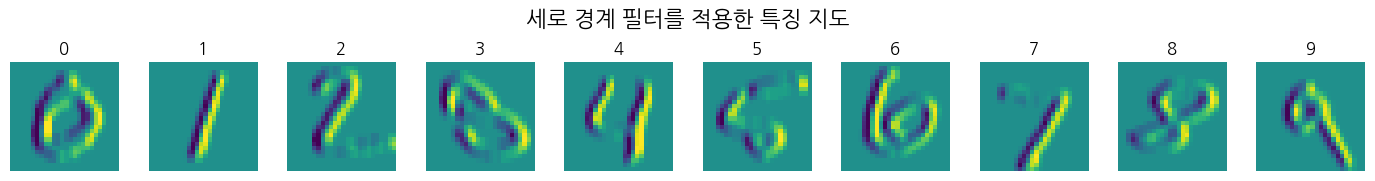

In [6]:
# 참고 - 원본에 대응되는 세로 경계 필터를 적용한 특징 지도([그림 5-7] 계속)

feature_maps = torch.stack(
    [make_feature_map(s, vertical_filter) for s in samples]
)
# (10, 26, 26) 형태를 (C, H, W) 로 간주해 plot_feature_map 사용
viz.plot_feature_map(
    feature_maps,
    title='세로 경계 필터를 적용한 특징 지도',
    images_per_row=10,
    channel_names=[f'{y}' for y in labels]
)

## 풀링으로 특징 지도 요약

- 풀링은 특징 지도를 일정 크기의 영역으로 나눠 각 영역을 대푯값 하나로 줄이는 연산이다.
    - 최대 풀링: 영역의 최댓값을 사용하며, 특징이 뚜렷한 위치를 남긴다.
    - 평균 풀링: 영역의 평균값을 사용하며, 특징이 영역 전체에 고르게 분포할 때 적합하다.
- 26x26 특징 지도를 커널 크기 2로 풀링하면 13x13으로 줄어든다([그림 5-8]).

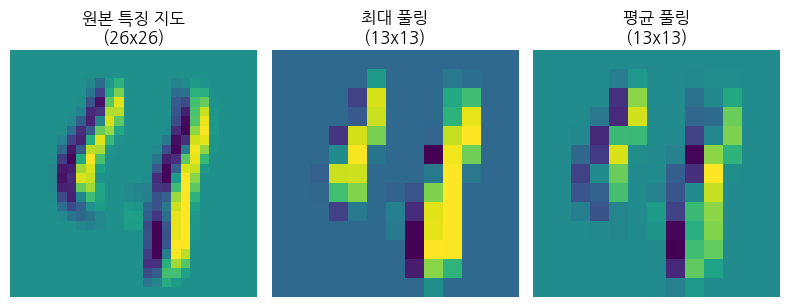

최대 풀링 후 크기: (13, 13)
평균 풀링 후 크기: (13, 13)


In [7]:
# 참고 - 26x26 특징 지도를 풀링한 결과 시각화(최대 풀링과 평균 풀링, [그림 5-8])
import torch.nn.functional as F

# 숫자 0 샘플의 특징 지도를 (1, 1, 26, 26) 형태로 풀링 API 입력에 맞춤
sample_map = feature_maps[4].unsqueeze(0).unsqueeze(0)
max_pooled = F.max_pool2d(sample_map, kernel_size=2)
avg_pooled = F.avg_pool2d(sample_map, kernel_size=2)

summary_maps = torch.stack([
    sample_map.squeeze(),                                   # (26, 26)
    F.interpolate(max_pooled, size=(26, 26)).squeeze(),
    F.interpolate(avg_pooled, size=(26, 26)).squeeze(),
])
viz.plot_feature_map(
    summary_maps,    
    images_per_row=3,
    channel_names=['원본 특징 지도\n(26x26)', '최대 풀링\n(13x13)', '평균 풀링\n(13x13)'],
    figsize=(8, 5),
)
print(f'최대 풀링 후 크기: {tuple(max_pooled.squeeze().shape)}')   # (13, 13)
print(f'평균 풀링 후 크기: {tuple(avg_pooled.squeeze().shape)}')   # (13, 13)

## 정리

- 합성곱은 두 텐서의 같은 위치 요소를 곱해 모두 더하는 연산으로, 결과는 스칼라값 하나다.
- 필터를 이미지 전체에 훑어 가며 합성곱하면 특징 지도가 만들어진다. 필터가 찾는 구조가 있는 위치일수록 값이 크다.
- 3x3 필터를 패딩 없이 적용하면 특징 지도는 가장자리만큼 작아진다(28x28 → 26x26).
- 풀링은 특징 지도를 요약해 크기를 줄이면서, 특징의 위치가 조금 달라져도 같은 결과를 내도록 돕는다.
- 이렇게 찾은 특징들을 겹쳐 조합하고 이 과정을 반복하는 구조가 합성곱 신경망이며, 5-2절에서 직접 만든다.